**Employee Productivity Prediction using Multiple Linear Regression**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.DataFrame({
    'Experience': [2, 5, 1, 8, 4, 10, 3, 6, 7, 2],
    'TrainingHours': [40, 60, 20, 80, 50, 90, 30, 70, 75, 25],
    'WorkingHours': [38, 42, 35, 45, 40, 48, 37, 44, 46, 36],
    'Projects': [3, 6, 2, 8, 5, 9, 4, 7, 7, 3],
    'ProductivityScore': [62, 78, 55, 88, 72, 92, 65, 82, 85, 60]
})
print("Dataset:")
print(df)

Dataset:
   Experience  TrainingHours  WorkingHours  Projects  ProductivityScore
0           2             40            38         3                 62
1           5             60            42         6                 78
2           1             20            35         2                 55
3           8             80            45         8                 88
4           4             50            40         5                 72
5          10             90            48         9                 92
6           3             30            37         4                 65
7           6             70            44         7                 82
8           7             75            46         7                 85
9           2             25            36         3                 60


In [ ]:
X = df[['Experience', 'TrainingHours', 'WorkingHours', 'Projects']]
y = df['ProductivityScore']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

Intercept: 78.16864608076
Coefficients:
Experience: -0.2637
TrainingHours: 0.2727
WorkingHours: -1.0855
Projects: 4.8860


In [ ]:
print("\nRegression Equation:")
print(
    f"ProductivityScore = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} * Experience) "
    f"+ ({model.coef_[1]:.4f} * TrainingHours) "
    f"+ ({model.coef_[2]:.4f} * WorkingHours) "
    f"+ ({model.coef_[3]:.4f} * Projects)"
)


Regression Equation:
ProductivityScore = 78.1686 + (-0.2637 * Experience) + (0.2727 * TrainingHours) + (-1.0855 * WorkingHours) + (4.8860 * Projects)


In [ ]:
print("\nModel Performance:")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)


Model Performance:
MSE : 8.396082170603862
RMSE: 2.8975993806259455
R2  : 0.3146055370935623


In [ ]:
# Example
new_employee = pd.DataFrame({
    'Experience': [5],
    'TrainingHours': [65],
    'WorkingHours': [42],
    'Projects': [6]
})
predicted_score = model.predict(new_employee)
print("Predicted Productivity Score:", predicted_score[0])

Predicted Productivity Score: 78.29928741092637


                   Experience  TrainingHours  WorkingHours  Projects  \
Experience           1.000000       0.969810      0.973178  0.988194   
TrainingHours        0.969810       1.000000      0.993132  0.977151   
WorkingHours         0.973178       0.993132      1.000000  0.974701   
Projects             0.988194       0.977151      0.974701  1.000000   
ProductivityScore    0.981991       0.987045      0.985684  0.995696   

                   ProductivityScore  
Experience                  0.981991  
TrainingHours               0.987045  
WorkingHours                0.985684  
Projects                    0.995696  
ProductivityScore           1.000000  


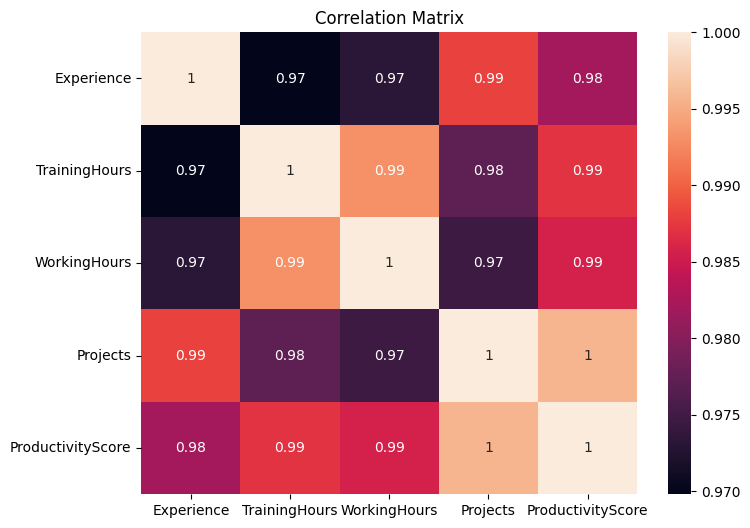

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr()
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

**Credit Card Fraud Detection using Logistic Regression**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.DataFrame({
    'TransactionID': [1,2,3,4,5,6,7,8,9,10],
    'Amount': [1200,50,5000,200,1500,75,3200,40,2100,60],
    'TimeSinceLastTxn': [2,24,1,48,3,72,2,96,5,120],
    'LocationChange': [1,0,1,0,1,0,1,0,1,0],
    'AvgTxnAmount': [500,200,450,300,700,150,400,100,600,120],
    'IsForeignTransaction': [1,0,1,0,1,0,1,0,1,0],
    'IsHighRiskCountry': [1,0,1,0,0,0,1,0,1,0],
    'CardPresent': [0,1,0,1,0,1,0,1,0,1],
    'IsFraud': [1,0,1,0,1,0,1,0,1,0]
})
print("Dataset:")
print(df)


Dataset:
   TransactionID  Amount  TimeSinceLastTxn  LocationChange  AvgTxnAmount  \
0              1    1200                 2               1           500   
1              2      50                24               0           200   
2              3    5000                 1               1           450   
3              4     200                48               0           300   
4              5    1500                 3               1           700   
5              6      75                72               0           150   
6              7    3200                 2               1           400   
7              8      40                96               0           100   
8              9    2100                 5               1           600   
9             10      60               120               0           120   

   IsForeignTransaction  IsHighRiskCountry  CardPresent  IsFraud  
0                     1                  1            0        1  
1                   

In [ ]:
X = df.drop(columns=['TransactionID', 'IsFraud'])
y = df['IsFraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
print("Intercept:", model.intercept_[0])
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Intercept: 0.512968316779262
Coefficients:
Amount: 0.3126
TimeSinceLastTxn: -0.3741
LocationChange: 0.4879
AvgTxnAmount: 0.4026
IsForeignTransaction: 0.4879
IsHighRiskCountry: 0.3278
CardPresent: -0.4879


In [ ]:
print("\nLogistic Regression Equation:")
print(
    f"log(p / (1-p)) = {model.intercept_[0]:.4f}"
    f" + ({model.coef_[0][0]:.4f} * Amount)"
    f" + ({model.coef_[0][1]:.4f} * TimeSinceLastTxn)"
    f" + ({model.coef_[0][2]:.4f} * LocationChange)"
    f" + ({model.coef_[0][3]:.4f} * AvgTxnAmount)"
    f" + ({model.coef_[0][4]:.4f} * IsForeignTransaction)"
    f" + ({model.coef_[0][5]:.4f} * IsHighRiskCountry)"
    f" + ({model.coef_[0][6]:.4f} * CardPresent)"
)



Logistic Regression Equation:
log(p / (1-p)) = 0.5130 + (0.3126 * Amount) + (-0.3741 * TimeSinceLastTxn) + (0.4879 * LocationChange) + (0.4026 * AvgTxnAmount) + (0.4879 * IsForeignTransaction) + (0.3278 * IsHighRiskCountry) + (-0.4879 * CardPresent)


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[2 0]
 [0 1]]


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 1.0
AUC: 1.0


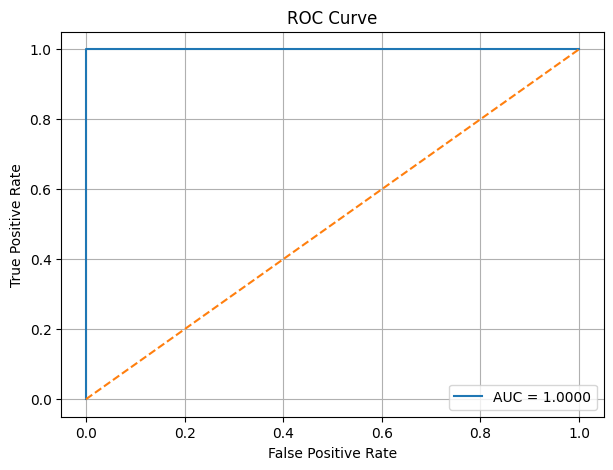

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("\nThreshold Tuning:")
threshold_values = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in threshold_values:
    custom_pred = (y_prob >= threshold).astype(int)
    print(f"\nThreshold = {threshold}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, custom_pred))
    print("Accuracy:", accuracy_score(y_test, custom_pred))


Threshold Tuning:

Threshold = 0.3
Confusion Matrix:
[[2 0]
 [0 1]]
Accuracy: 1.0

Threshold = 0.4
Confusion Matrix:
[[2 0]
 [0 1]]
Accuracy: 1.0

Threshold = 0.5
Confusion Matrix:
[[2 0]
 [0 1]]
Accuracy: 1.0

Threshold = 0.6
Confusion Matrix:
[[2 0]
 [0 1]]
Accuracy: 1.0

Threshold = 0.7
Confusion Matrix:
[[2 0]
 [0 1]]
Accuracy: 1.0


In [ ]:
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0)
l2_model = LogisticRegression(penalty='l2', solver='liblinear', C=1.0)

l1_model.fit(X_train_scaled, y_train)
l2_model.fit(X_train_scaled, y_train)

l1_prob = l1_model.predict_proba(X_test_scaled)[:, 1]
l2_prob = l2_model.predict_proba(X_test_scaled)[:, 1]

l1_auc = roc_auc_score(y_test, l1_prob)
l2_auc = roc_auc_score(y_test, l2_prob)

print("\nRegularization Comparison:")
print("L1 AUC:", l1_auc)
print("L2 AUC:", l2_auc)

print("\nL1 Coefficients:")
for feature, coef in zip(X.columns, l1_model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

print("\nL2 Coefficients:")
for feature, coef in zip(X.columns, l2_model.coef_[0]):
    print(f"{feature}: {coef:.4f}")


Regularization Comparison:
L1 AUC: 1.0
L2 AUC: 1.0

L1 Coefficients:
Amount: 0.0000
TimeSinceLastTxn: 0.0000
LocationChange: 1.7416
AvgTxnAmount: 0.0000
IsForeignTransaction: 0.0431
IsHighRiskCountry: 0.0000
CardPresent: 0.0000

L2 Coefficients:
Amount: 0.3006
TimeSinceLastTxn: -0.3882
LocationChange: 0.4874
AvgTxnAmount: 0.4163
IsForeignTransaction: 0.4874
IsHighRiskCountry: 0.3204
CardPresent: -0.4874


In [ ]:
print("\nEnter new transaction details:")
amount = float(input("Amount: "))
time_since_last_txn = float(input("TimeSinceLastTxn (hours): "))
location_change = int(input("LocationChange (0 = No, 1 = Yes): "))
avg_txn_amount = float(input("AvgTxnAmount: "))
is_foreign_transaction = int(input("IsForeignTransaction (0 = No, 1 = Yes): "))
is_high_risk_country = int(input("IsHighRiskCountry (0 = No, 1 = Yes): "))
card_present = int(input("CardPresent (0 = No, 1 = Yes): "))
new_txn = pd.DataFrame({
            "Amount": [amount],
            "TimeSinceLastTxn": [time_since_last_txn],
            "LocationChange": [location_change],
            "AvgTxnAmount": [avg_txn_amount],
            "IsForeignTransaction": [is_foreign_transaction],
            "IsHighRiskCountry": [is_high_risk_country],
            "CardPresent": [card_present]
        })
new_txn_scaled = scaler.transform(new_txn)
fraud_probability = model.predict_proba(new_txn_scaled)[0, 1]
prediction = 1 if fraud_probability >= threshold else 0
print("\n--- Prediction Result ---")
print("Fraud Probability:", round(fraud_probability, 4))
print("Threshold Used:", round(threshold, 4))
if prediction == 1:
  print("Classified as: Fraud")
else:
  print("Classified as: Legitimate")


Enter new transaction details:
Amount: 5000
TimeSinceLastTxn (hours): 1
LocationChange (0 = No, 1 = Yes): 1
AvgTxnAmount: 450
IsForeignTransaction (0 = No, 1 = Yes): 1
IsHighRiskCountry (0 = No, 1 = Yes): 1
CardPresent (0 = No, 1 = Yes): 0

--- Prediction Result ---
Fraud Probability: 0.962
Threshold Used: 0.7
Classified as: Fraud


**Customer Segmentation using K-Means Clustering**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.DataFrame({
    'CustomerID': [1,2,3,4,5,6,7,8,9,10],
    'Age': [22,25,47,52,23,45,33,35,60,28],
    'AnnualIncome': [15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    'SpendingScore': [39,81,6,20,77,15,50,55,10,70],
    'VisitsPerMonth': [4,6,2,3,5,2,4,5,1,6],
    'AvgOrderValue': [200,500,150,200,450,180,300,320,100,400]
})

print("Dataset:")
print(df)

Dataset:
   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450
5           6   45         70000             15               2            180
6           7   33         40000             50               4            300
7           8   35         42000             55               5            320
8           9   60         80000             10               1            100
9          10   28         30000             70               6            400


In [ ]:
print("\nNull values:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())


Null values:
CustomerID        0
Age               0
AnnualIncome      0
SpendingScore     0
VisitsPerMonth    0
AvgOrderValue     0
dtype: int64

Summary statistics:
       CustomerID        Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
count    10.00000  10.000000     10.000000      10.000000        10.00000   
mean      5.50000  37.000000  44000.000000      42.300000         3.80000   
std       3.02765  13.266499  23518.314376      28.488009         1.75119   
min       1.00000  22.000000  15000.000000       6.000000         1.00000   
25%       3.25000  25.750000  22500.000000      16.250000         2.25000   
50%       5.50000  34.000000  41000.000000      44.500000         4.00000   
75%       7.75000  46.500000  63750.000000      66.250000         5.00000   
max      10.00000  60.000000  80000.000000      81.000000         6.00000   

       AvgOrderValue  
count      10.000000  
mean      280.000000  
std       135.728487  
min       100.000000  
25%       185.000000  


In [ ]:
X = df[['Age', 'AnnualIncome', 'SpendingScore', 'VisitsPerMonth', 'AvgOrderValue']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardized Feature Values:")
print(X_scaled)


Standardized Feature Values:
[[-1.19182824 -1.2997821  -0.12210419  0.12038585 -0.62129481]
 [-0.95346259 -1.16532188  1.4319492   1.32424438  1.70856072]
 [ 0.79455216  0.71712116 -1.34314614 -1.08347268 -1.00960406]
 [ 1.19182824  0.94122152 -0.82512835 -0.48154341 -0.62129481]
 [-1.11237302 -1.07568174  1.28394411  0.72231512  1.32025147]
 [ 0.63564173  1.16532188 -1.0101347  -1.08347268 -0.77661851]
 [-0.31782086 -0.17928029  0.28490979  0.12038585  0.1553237 ]
 [-0.15891043 -0.08964014  0.46991614  0.72231512  0.3106474 ]
 [ 1.82746996  1.61352261 -1.19514106 -1.68540194 -1.39791332]
 [-0.71509694 -0.62748101  1.02493521  1.32424438  0.93194221]]


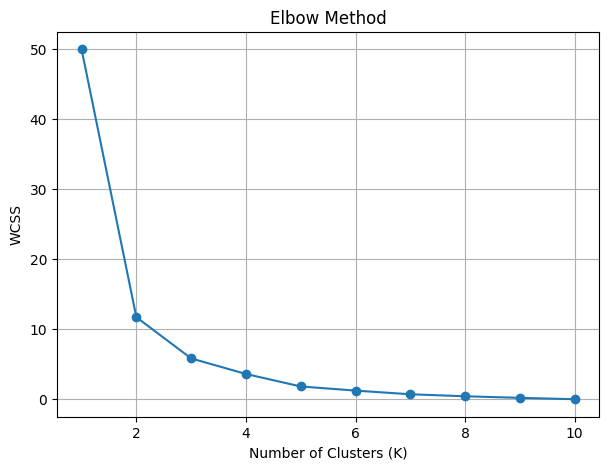

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [ ]:
print("\nSilhouette Scores:")
silhouette_scores = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"K = {k}, Silhouette Score = {score:.4f}")


Silhouette Scores:
K = 2, Silhouette Score = 0.6073
K = 3, Silhouette Score = 0.5203
K = 4, Silhouette Score = 0.5134
K = 5, Silhouette Score = 0.4187
K = 6, Silhouette Score = 0.3034
K = 7, Silhouette Score = 0.2244
K = 8, Silhouette Score = 0.1736
K = 9, Silhouette Score = 0.0663


In [ ]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal K based on Silhouette Score: {best_k}")


Optimal K based on Silhouette Score: 2


In [ ]:
#Apply K-Means with k = 3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

In [ ]:
print("\nCustomer Cluster Labels:")
print(df[['CustomerID', 'Cluster']])


Customer Cluster Labels:
   CustomerID  Cluster
0           1        2
1           2        1
2           3        0
3           4        0
4           5        1
5           6        0
6           7        2
7           8        2
8           9        0
9          10        1


In [ ]:
centroids_scaled = pd.DataFrame(kmeans_final.cluster_centers_, columns=X.columns)
print("\nCluster Centroids (Scaled):")
print(centroids_scaled)

centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=X.columns
)
print("\nCluster Centroids (Original Scale):")
print(centroids_original)



Cluster Centroids (Scaled):
        Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  1.112373      1.109297      -1.093388       -1.083473      -0.951358
1 -0.926978     -0.956162       1.246943        1.123601       1.320251
2 -0.556187     -0.522901       0.210907        0.321029      -0.051775

Cluster Centroids (Original Scale):
         Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  51.000000  68750.000000          12.75        2.000000     157.500000
1  25.333333  22666.666667          76.00        5.666667     450.000000
2  30.000000  32333.333333          48.00        4.333333     273.333333
